In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Đọc dữ liệu
df = pd.read_csv('processed_dulieuxettuyendaihoc.csv')

# 1. Sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần
df_sorted_dh1 = df.sort_values(by='DH1', ascending=True)
print("--- CÂU 1: DH1 tăng dần ---")
print(df_sorted_dh1[['GT', 'DH1']].head())

# 2. Sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính
df_sorted_dh2_gt = df.sort_values(by=['GT', 'DH2'], ascending=[True, True])
print("\n--- CÂU 2: DH2 tăng dần theo Giới tính ---")
print(df_sorted_dh2_gt[['GT', 'DH2']].head())

# Định nghĩa các hàm để tính Tứ phân vị trong Pivot Table
def q1(x): return x.quantile(0.25)
def q2(x): return x.quantile(0.50)
def q3(x): return x.quantile(0.75)

agg_list = ['count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, q2, q3]
rename_dict = {'q1': 'Q1', 'q2': 'Q2', 'q3': 'Q3'}

# 3. Pivot-table của DH1 theo KT
pivot_c3 = df.pivot_table(values='DH1', index='KT', aggfunc=agg_list).rename(columns=rename_dict)
print("\n--- CÂU 3: Thống kê DH1 theo KT ---")
print(pivot_c3)

# 4. Pivot-table của DH1 theo KT và KV
pivot_c4 = df.pivot_table(values='DH1', index=['KT', 'KV'], aggfunc=agg_list).rename(columns=rename_dict)
print("\n--- CÂU 4: Thống kê DH1 theo KT và KV ---")
print(pivot_c4)

# 5. Pivot-table của DH1 theo KT, KV và DT
pivot_c5 = df.pivot_table(values='DH1', index=['KT', 'KV', 'DT'], aggfunc=agg_list).rename(columns=rename_dict)
print("\n--- CÂU 5: Thống kê DH1 theo KT, KV và DT ---")
print(pivot_c5)

--- CÂU 1: DH1 tăng dần ---
   GT   DH1
53  M  1.00
43  F  1.25
72  M  1.50
5   M  1.50
87  M  1.75

--- CÂU 2: DH2 tăng dần theo Giới tính ---
   GT   DH2
95  F  1.50
25  F  2.00
24  F  2.25
46  F  2.25
13  F  2.75

--- CÂU 3: Thống kê DH1 theo KT ---
   count     sum      mean median   min   max       std      Q1    Q2     Q3
     DH1     DH1       DH1    DH1   DH1   DH1       DH1     DH1   DH1    DH1
KT                                                                          
A     49  163.50  3.336735   3.25  1.00  6.50  1.274296  2.2500  3.25  4.250
A1     6   17.50  2.916667   3.00  2.00  4.25  0.861201  2.1875  3.00  3.250
B      9   29.50  3.277778   3.50  1.75  4.50  0.823905  3.2500  3.50  3.750
C     14   79.25  5.660714   5.25  4.75  7.00  0.812209  5.0625  5.25  6.375
D1    22   84.25  3.829545   3.75  1.25  6.75  1.370146  3.0000  3.75  4.875

--- CÂU 4: Thống kê DH1 theo KT và KV ---
       count    sum      mean median   min   max       std      Q1     Q2  \
         DH

--- CÂU 1: Bảng tần số/tần suất GT ---
    Tần số  Tần suất (%)
GT                      
M       52          52.0
F       48          48.0


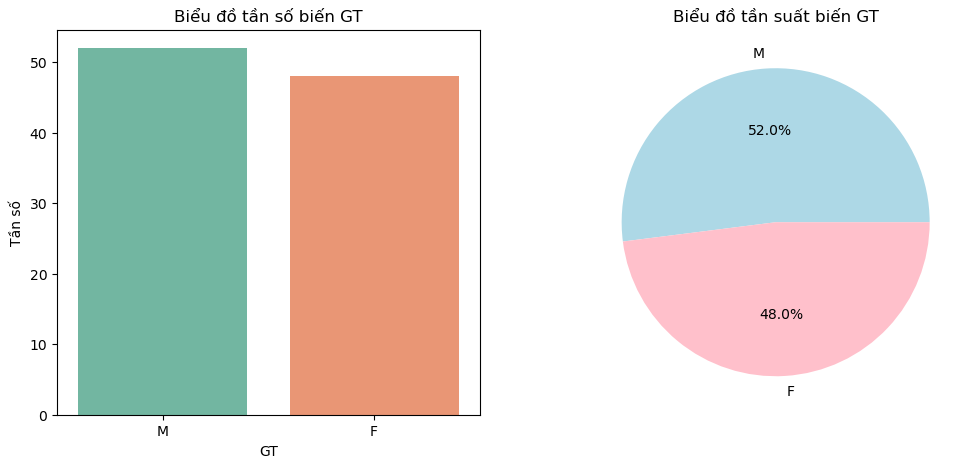


--- CÂU 2: Thống kê mô tả US_TBM ---
          US_TBM1     US_TBM2    US_TBM3
count  100.000000  100.000000  100.00000
mean     2.434480    2.559600    2.67176
std      0.391203    0.377656    0.29981
min      1.616000    1.768000    1.91600
25%      2.107000    2.223000    2.47300
50%      2.480000    2.588000    2.70600
75%      2.724000    2.893000    2.87400
max      3.232000    3.416000    3.31600


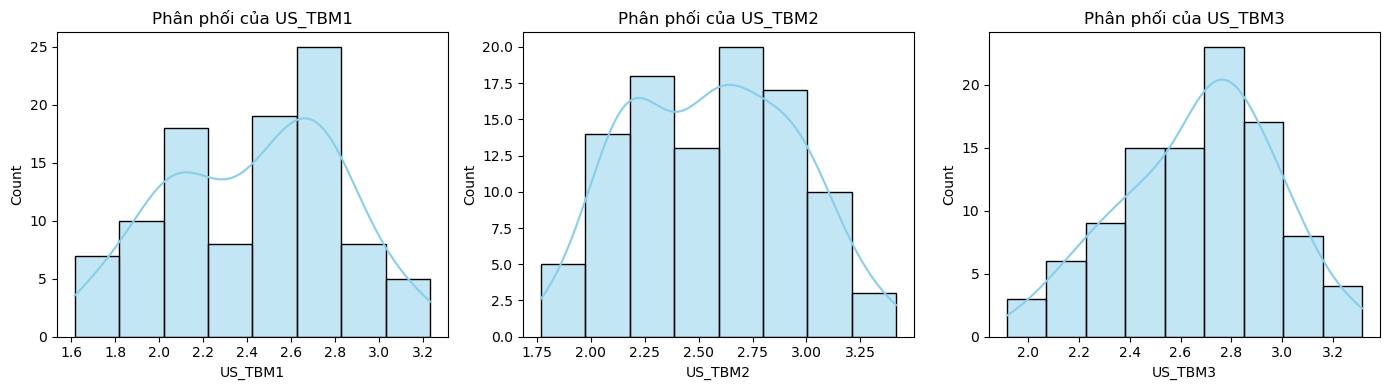


--- CÂU 3: Tần số DT của học sinh Nam ---
     Số lượng
DT           
0.0        50
1.0         1
6.0         1


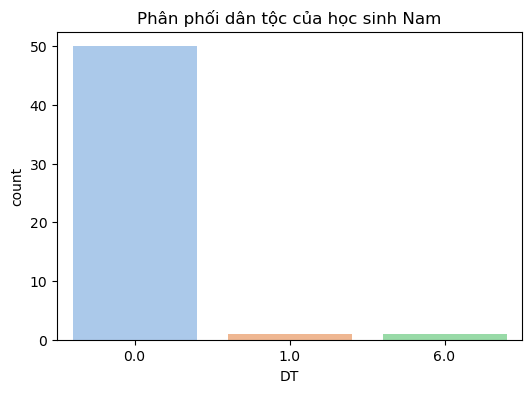


--- CÂU 4: Phân phối KV thỏa điều kiện phức tạp ---
Series([], Name: count, dtype: int64)


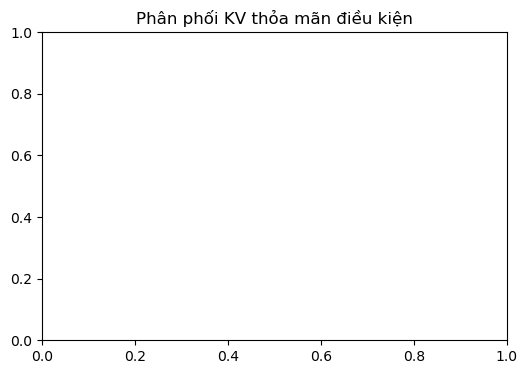


--- CÂU 5: Thống kê DH1, DH2, DH3 nhóm KV 2NT (đều >= 5.0) ---
        DH1   DH2  DH3
count  1.00  1.00  1.0
mean   6.75  5.25  5.0
std     NaN   NaN  NaN
min    6.75  5.25  5.0
25%    6.75  5.25  5.0
50%    6.75  5.25  5.0
75%    6.75  5.25  5.0
max    6.75  5.25  5.0


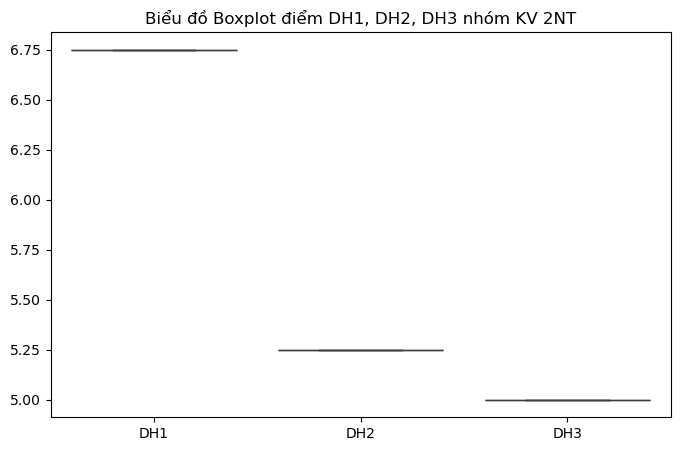

In [32]:
# 1. Trình bày dữ liệu biến: GT
tb_gt = pd.DataFrame()
tb_gt['Tần số'] = df['GT'].value_counts()
tb_gt['Tần suất (%)'] = df['GT'].value_counts(normalize=True) * 100
print("--- CÂU 1: Bảng tần số/tần suất GT ---")
print(tb_gt)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# SỬA LỖI: Thêm hue và legend=False
sns.barplot(x=tb_gt.index, y=tb_gt['Tần số'], ax=axes[0], hue=tb_gt.index, palette='Set2', legend=False)
axes[0].set_title('Biểu đồ tần số biến GT')

axes[1].pie(tb_gt['Tần suất (%)'], labels=tb_gt.index, autopct='%1.1f%%', colors=['lightblue', 'pink'])
axes[1].set_title('Biểu đồ tần suất biến GT')
plt.show()

# 2. Trình bày dữ liệu biến: US_TBM1, US_TBM2 và US_TBM3
vars_tbm = ['US_TBM1', 'US_TBM2', 'US_TBM3']
print("\n--- CÂU 2: Thống kê mô tả US_TBM ---")
print(df[vars_tbm].describe())

plt.figure(figsize=(14, 4))
for i, var in enumerate(vars_tbm, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[var], kde=True, color='skyblue')
    plt.title(f'Phân phối của {var}')
plt.tight_layout()
plt.show()

# 3. Trình bày dữ liệu biến DT với học sinh nam (Giả định mã hóa Nam là 'M')
df_nam = df[df['GT'] == 'M'] 
tb_dt_nam = df_nam['DT'].value_counts().to_frame(name='Số lượng')
print("\n--- CÂU 3: Tần số DT của học sinh Nam ---")
print(tb_dt_nam)

plt.figure(figsize=(6, 4))
# SỬA LỖI: Thêm hue và legend=False
sns.countplot(data=df_nam, x='DT', hue='DT', palette='pastel', legend=False)
plt.title('Phân phối dân tộc của học sinh Nam')
plt.show()

# 4. Trình bày biến KV với học sinh nam, Kinh, điểm (DH1 >= 5, DH2 >= 4, DH3 >= 4)
df_filter_c4 = df[(df['GT'] == 'M') & (df['DT'] == 'Kinh') & (df['DH1'] >= 5.0) & (df['DH2'] >= 4.0) & (df['DH3'] >= 4.0)]
print("\n--- CÂU 4: Phân phối KV thỏa điều kiện phức tạp ---")
print(df_filter_c4['KV'].value_counts())

plt.figure(figsize=(6, 4))
# SỬA LỖI: Thêm hue và legend=False
sns.countplot(data=df_filter_c4, x='KV', hue='KV', palette='autumn', legend=False)
plt.title('Phân phối KV thỏa mãn điều kiện')
plt.show()

# 5. Trình bày biến DH1, DH2, DH3 >= 5.0 và thuộc khu vực 2NT
df_filter_c5 = df[(df['DH1'] >= 5.0) & (df['DH2'] >= 5.0) & (df['DH3'] >= 5.0) & (df['KV'] == '2NT')]
print("\n--- CÂU 5: Thống kê DH1, DH2, DH3 nhóm KV 2NT (đều >= 5.0) ---")
print(df_filter_c5[['DH1', 'DH2', 'DH3']].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_filter_c5[['DH1', 'DH2', 'DH3']])
plt.title('Biểu đồ Boxplot điểm DH1, DH2, DH3 nhóm KV 2NT')
plt.show()

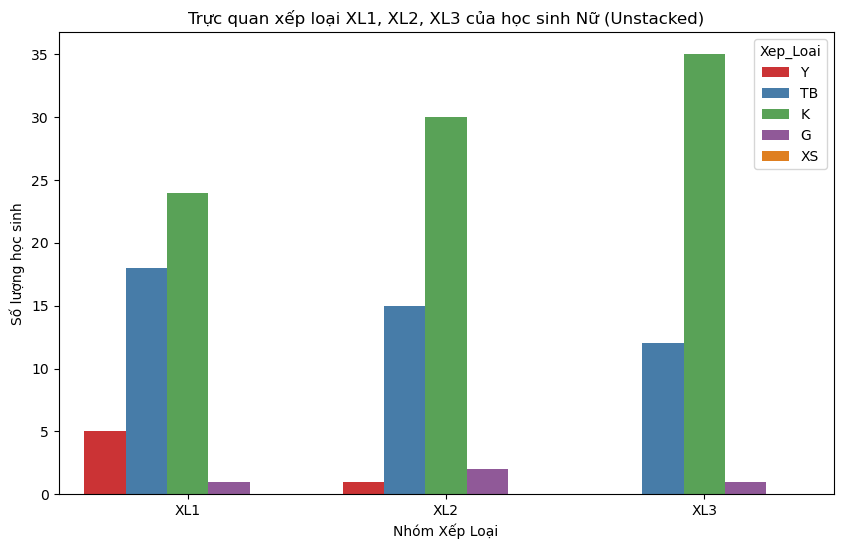

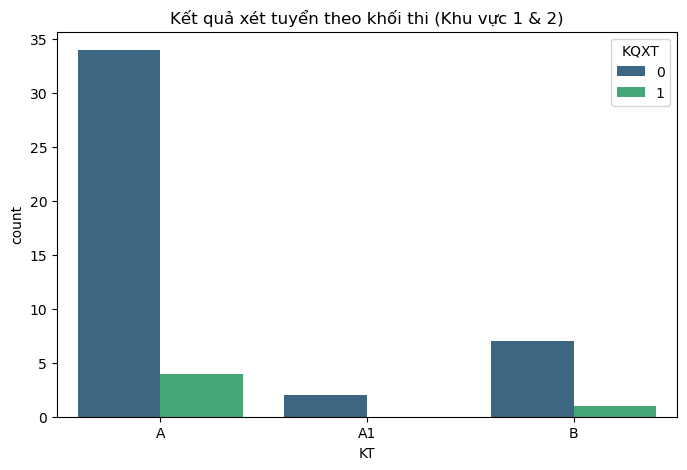

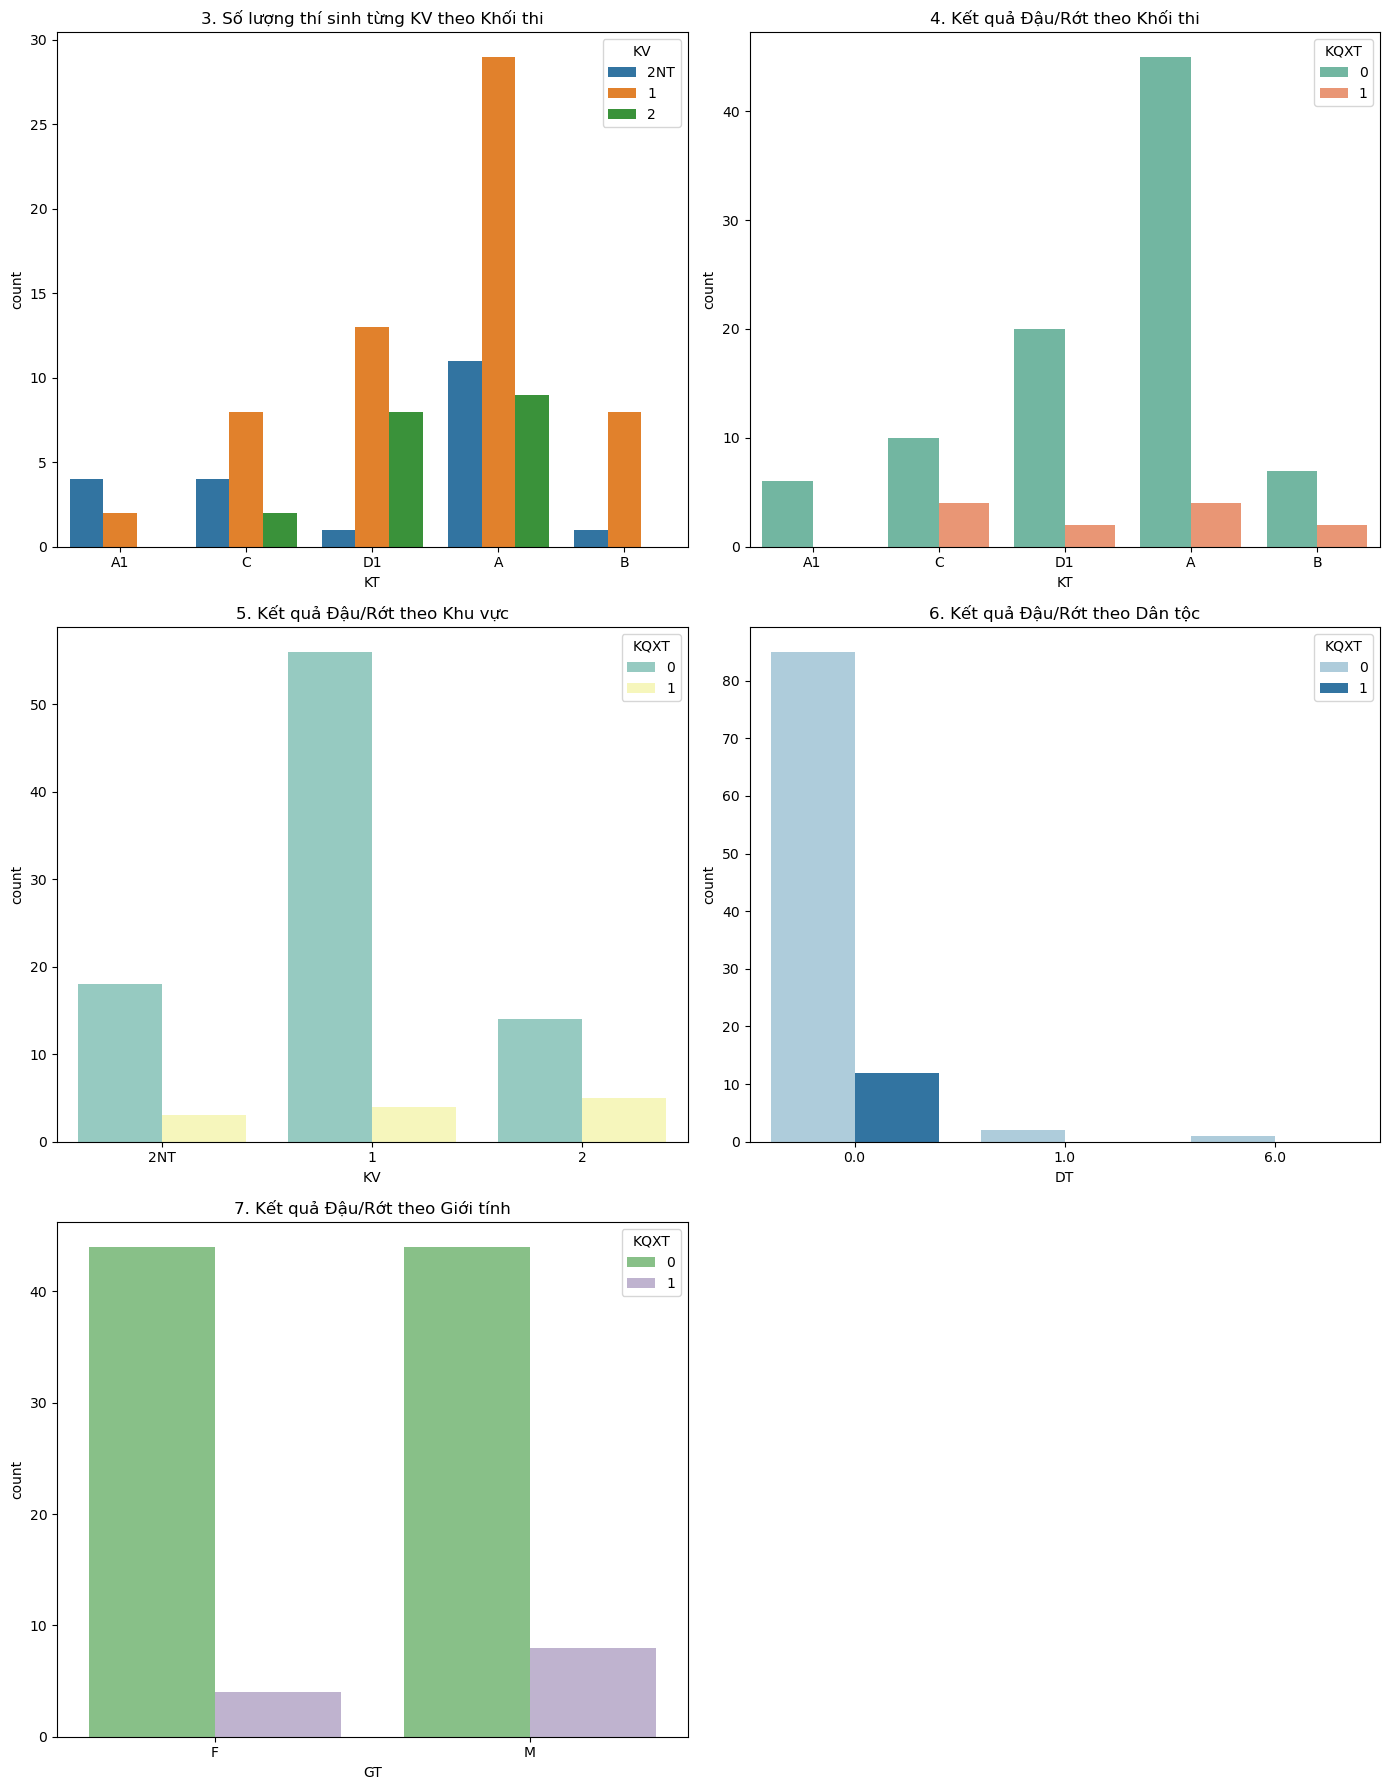

In [33]:
# 1. Trực quan dữ liệu học sinh nữ trên các nhóm XL1, XL2, XL3 dạng unstacked
df_nu = df[df['GT'] == 'F'] # Giả định Nữ là 'F'
df_xl_long = df_nu.melt(value_vars=['XL1', 'XL2', 'XL3'], var_name='Nhom_XL', value_name='Xep_Loai')

plt.figure(figsize=(10, 6))
sns.countplot(data=df_xl_long, x='Nhom_XL', hue='Xep_Loai', hue_order=['Y', 'TB', 'K', 'G', 'XS'], palette='Set1')
plt.ylabel('Số lượng học sinh')
plt.xlabel('Nhóm Xếp Loại')
plt.title('Trực quan xếp loại XL1, XL2, XL3 của học sinh Nữ (Unstacked)')
plt.show()

# 2. Trực quan KQXT trên nhóm học sinh khối A, A1, B thuộc KV 1, 2
df_c3_2 = df[df['KT'].isin(['A', 'A1', 'B']) & df['KV'].isin(['1', '2'])]
plt.figure(figsize=(8, 5))
sns.countplot(data=df_c3_2, x='KT', hue='KQXT', palette='viridis')
plt.title('Kết quả xét tuyển theo khối thi (Khu vực 1 & 2)')
plt.show()

# 3 -> 7. gom chung vào một Figure gồm nhiều ô đồ thị nhỏ
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# 3. Số lượng thí sinh từng KV dựa trên từng nhóm khối thi
sns.countplot(data=df, x='KT', hue='KV', ax=axes[0,0], palette='tab10')
axes[0,0].set_title('3. Số lượng thí sinh từng KV theo Khối thi')

# 4. Số lượng thí sinh đậu, rớt trên từng nhóm khối thi
sns.countplot(data=df, x='KT', hue='KQXT', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('4. Kết quả Đậu/Rớt theo Khối thi')

# 5. Số lượng thí sinh đậu rớt trên từng nhóm khu vực
sns.countplot(data=df, x='KV', hue='KQXT', ax=axes[1,0], palette='Set3')
axes[1,0].set_title('5. Kết quả Đậu/Rớt theo Khu vực')

# 6. Số lượng thí sinh đậu rớt dựa trên từng nhóm dân tộc
sns.countplot(data=df, x='DT', hue='KQXT', ax=axes[1,1], palette='Paired')
axes[1,1].set_title('6. Kết quả Đậu/Rớt theo Dân tộc')

# 7. Số lượng thí sinh đậu rớt dựa trên từng nhóm giới tính
sns.countplot(data=df, x='GT', hue='KQXT', ax=axes[2,0], palette='Accent')
axes[2,0].set_title('7. Kết quả Đậu/Rớt theo Giới tính')

# Xóa subplot trống cuối cùng
fig.delaxes(axes[2,1])

plt.tight_layout()
plt.show()

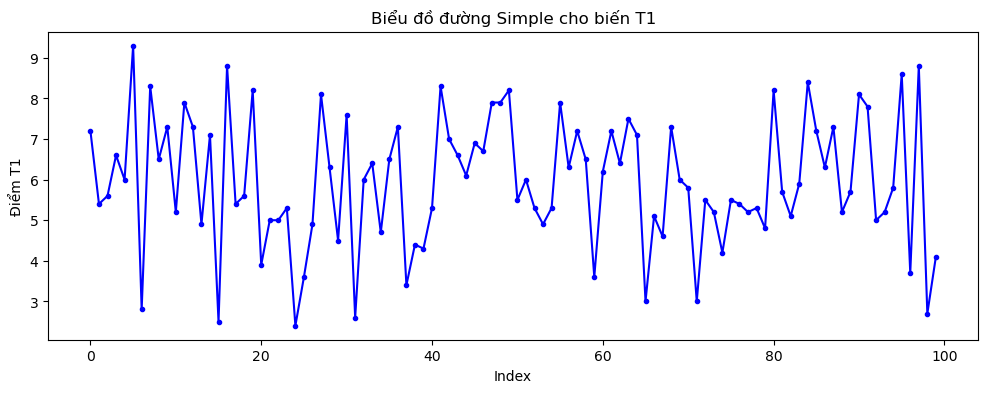

--- CÂU 3: Bảng tần số phanlopt1 ---
           Tần số
phanlopt1        
tb             46
k              23
kh             19
g              12


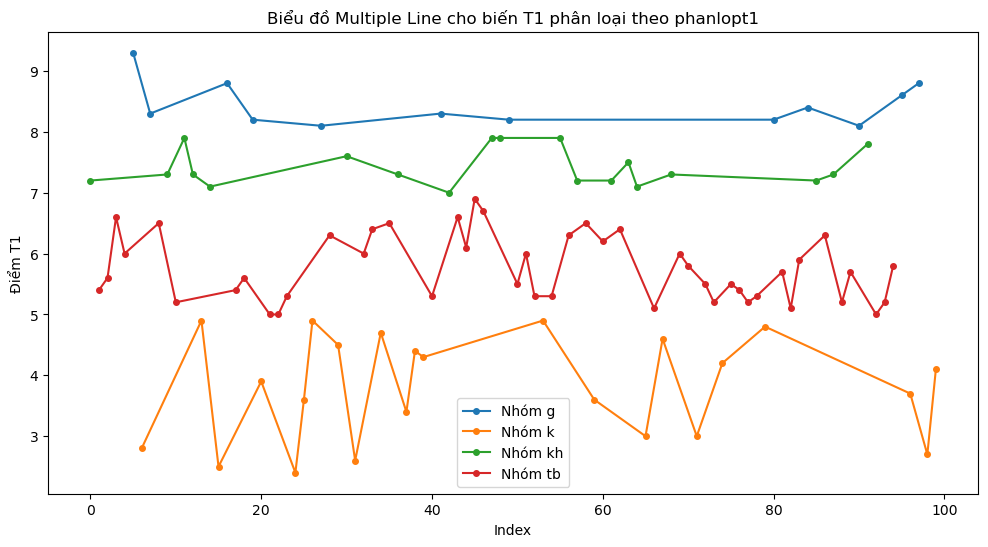

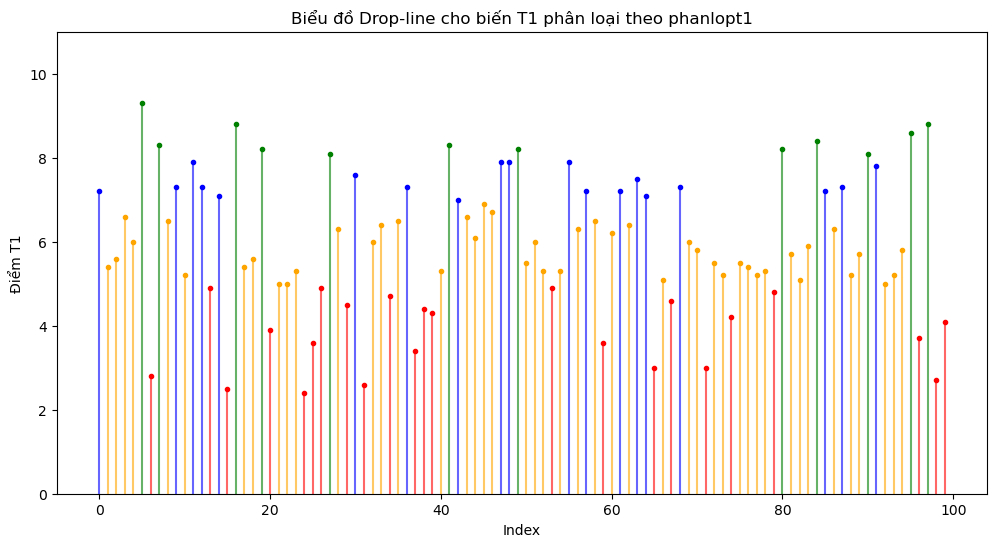

In [34]:
# 1. Vẽ biểu đồ đường Simple cho biến T1
plt.figure(figsize=(12, 4))
plt.plot(df['T1'], marker='o', linestyle='-', color='b', markersize=3)
plt.title('Biểu đồ đường Simple cho biến T1')
plt.xlabel('Index')
plt.ylabel('Điểm T1')
plt.show()

# 2. Tạo biến phân loại (phanlopt1) cho môn toán (T1)
def phan_loai_t1(diem):
    if diem < 5: return 'k'
    elif diem < 7: return 'tb'
    elif diem < 8: return 'kh'
    else: return 'g'

df['phanlopt1'] = df['T1'].apply(phan_loai_t1)

# 3. Lập bảng tần số cho biến phanloait1
tb_phanloait1 = df['phanlopt1'].value_counts().to_frame(name='Tần số')
print("--- CÂU 3: Bảng tần số phanlopt1 ---")
print(tb_phanloait1)

# 4. Vẽ biểu đồ đường Multiple Line cho biến T1 phân loại bởi phanlopt1
plt.figure(figsize=(12, 6))
for nhom, data in df.groupby('phanlopt1'):
    plt.plot(data.index, data['T1'], marker='o', linestyle='-', label=f'Nhóm {nhom}', markersize=4)
plt.title('Biểu đồ Multiple Line cho biến T1 phân loại theo phanlopt1')
plt.xlabel('Index')
plt.ylabel('Điểm T1')
plt.legend()
plt.show()

# 5. Vẽ biểu đồ Drop-line cho biến T1 phân loại bởi phanlopt1
plt.figure(figsize=(12, 6))
colors = {'k': 'red', 'tb': 'orange', 'kh': 'blue', 'g': 'green'}
for idx, row in df.iterrows():
    plt.vlines(x=idx, ymin=0, ymax=row['T1'], colors=colors[row['phanlopt1']], alpha=0.6)
    plt.plot(idx, row['T1'], marker='o', color=colors[row['phanlopt1']], markersize=3)
plt.title('Biểu đồ Drop-line cho biến T1 phân loại theo phanlopt1')
plt.xlabel('Index')
plt.ylabel('Điểm T1')
plt.ylim(0, 11)
plt.show()

--- CÂU 1: Thống kê mô tả hình dáng T1 ---
Mean: 5.95, Median: 5.85, Std: 1.61
Skewness (Độ lệch): -0.18, Kurtosis (Độ nhọn): -0.48


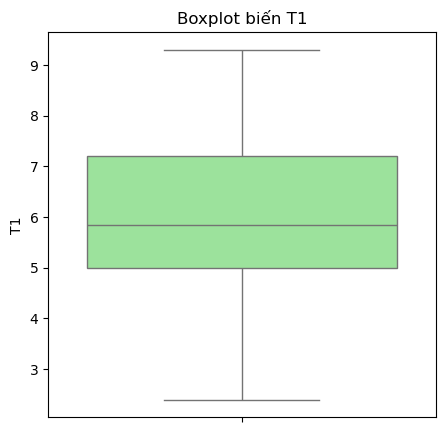

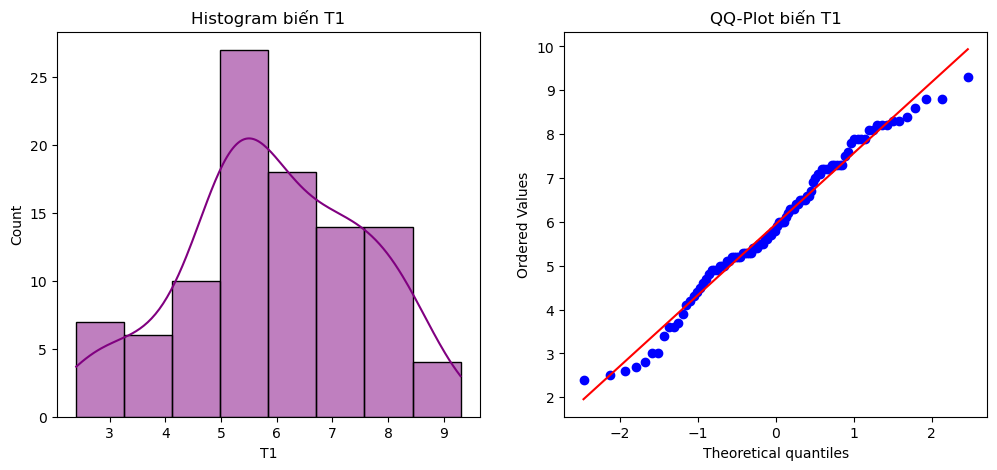

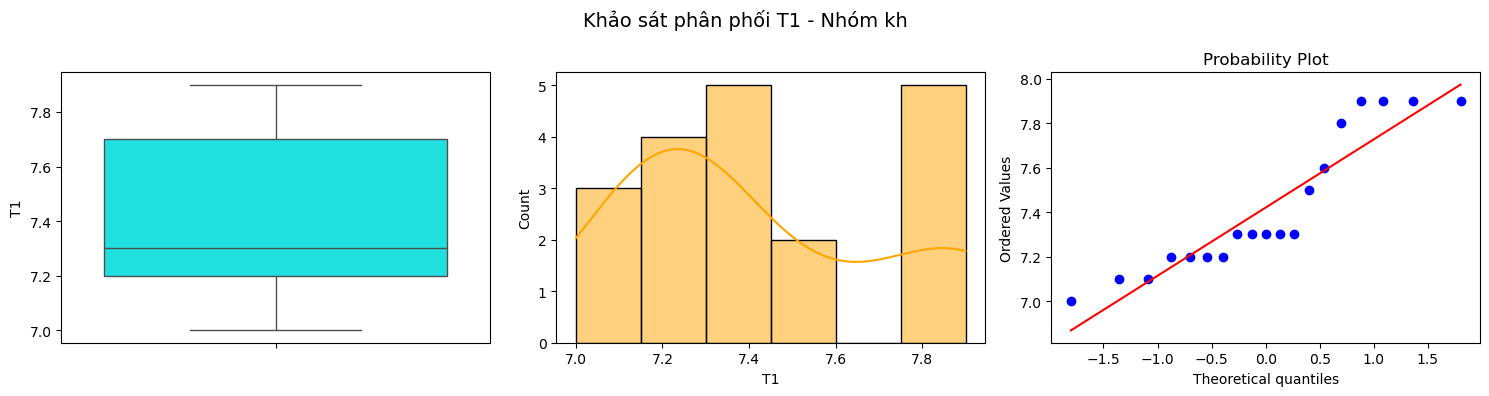

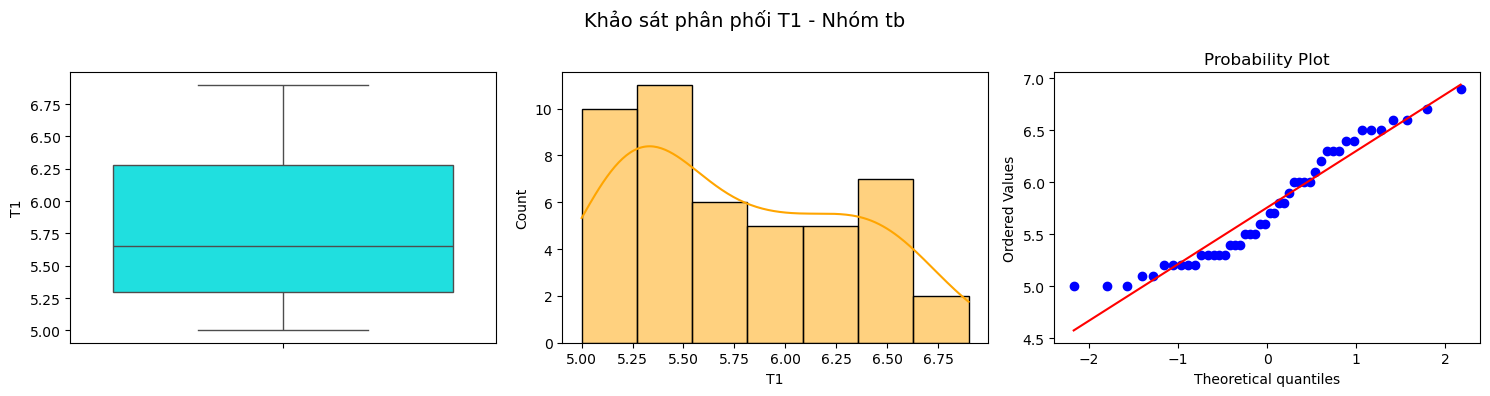

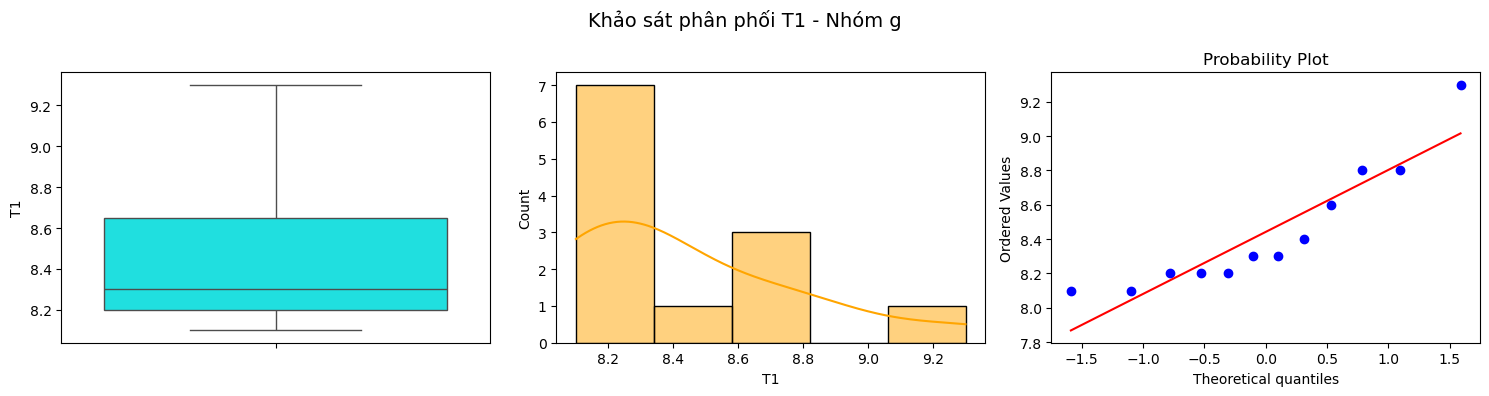

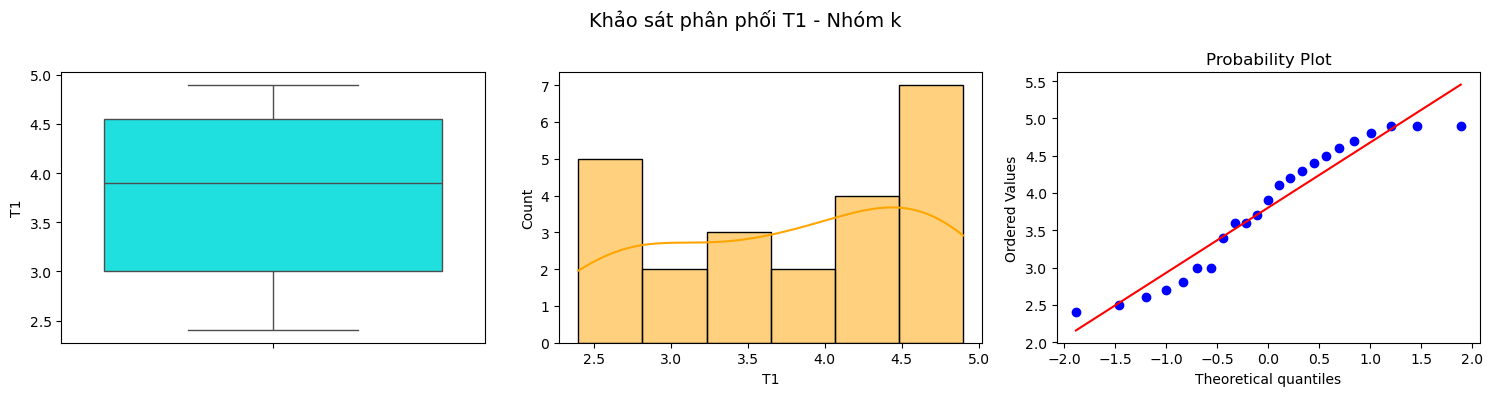


--- CÂU 3: Tương quan DH1 và T1 ---
Hiệp phương sai: 0.113
Hệ số tương quan: 0.049


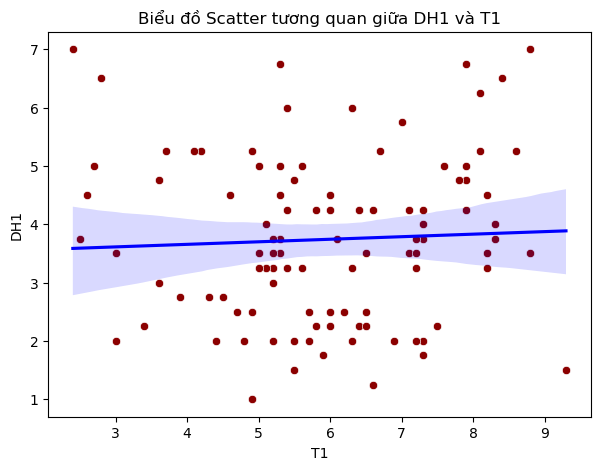

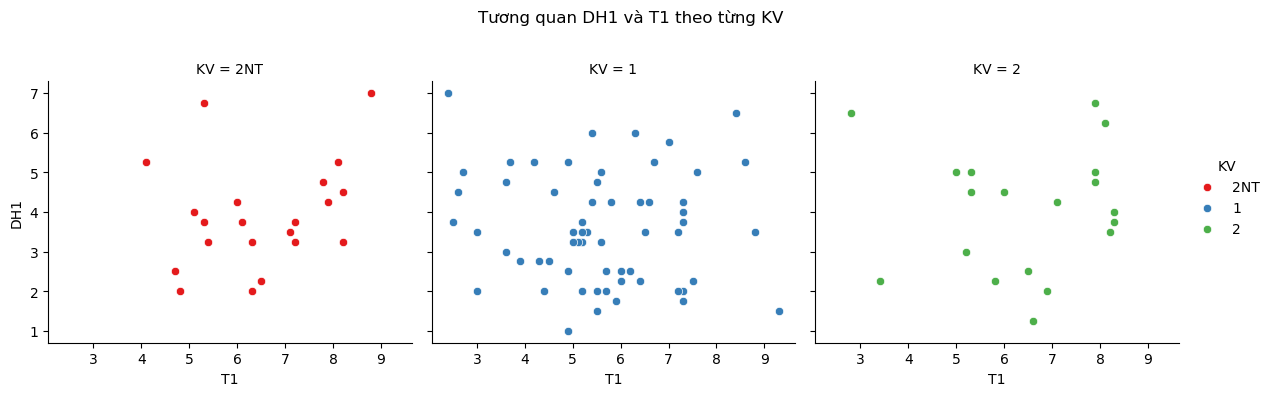


--- CÂU 5: Ma trận Hiệp Phương Sai ---
          DH1       DH2       DH3
DH1  2.028939  0.053081  0.027778
DH2  0.053081  1.123712 -0.101010
DH3  0.027778 -0.101010  1.083965

--- Ma trận Tương Quan ---
          DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000


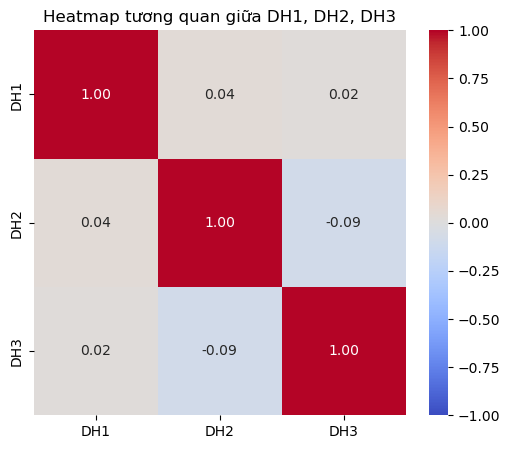

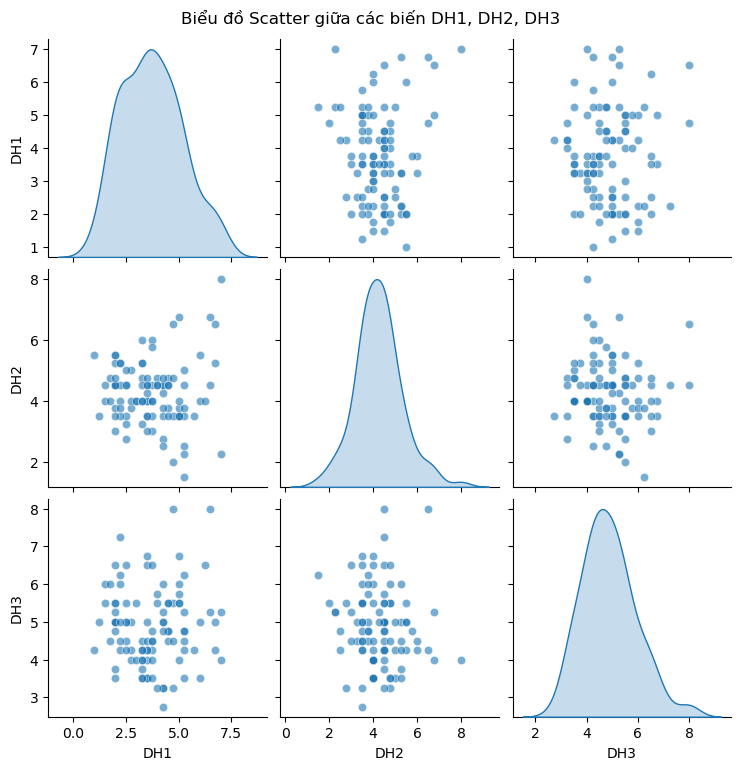

In [35]:
# 1. Khảo sát phân phối cho biến T1
print("--- CÂU 1: Thống kê mô tả hình dáng T1 ---")
print(f"Mean: {df['T1'].mean():.2f}, Median: {df['T1'].median():.2f}, Std: {df['T1'].std():.2f}")
print(f"Skewness (Độ lệch): {df['T1'].skew():.2f}, Kurtosis (Độ nhọn): {df['T1'].kurt():.2f}")

# Vẽ Box-plot
plt.figure(figsize=(5, 5))
sns.boxplot(y=df['T1'], color='lightgreen')
plt.title('Boxplot biến T1')
plt.show()

# Vẽ Histogram và QQ-Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['T1'], kde=True, ax=axes[0], color='purple')
axes[0].set_title('Histogram biến T1')
stats.probplot(df['T1'], dist="norm", plot=axes[1])
axes[1].set_title('QQ-Plot biến T1')
plt.show()

# 2. Khảo sát phân phối biến T1 trên từng nhóm phân lớp (phanlopt1)
for nhom in df['phanlopt1'].unique():
    df_sub = df[df['phanlopt1'] == nhom]
    if len(df_sub) > 1:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'Khảo sát phân phối T1 - Nhóm {nhom}', fontsize=14)
        sns.boxplot(y=df_sub['T1'], ax=axes[0], color='cyan')
        sns.histplot(df_sub['T1'], kde=True, ax=axes[1], color='orange')
        stats.probplot(df_sub['T1'], dist="norm", plot=axes[2])
        plt.tight_layout()
        plt.show()

# 3. Tương quan giữa biến DH1 theo biến T1
print("\n--- CÂU 3: Tương quan DH1 và T1 ---")
print(f"Hiệp phương sai: {df['DH1'].cov(df['T1']):.3f}")
print(f"Hệ số tương quan: {df['DH1'].corr(df['T1']):.3f}")

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='T1', y='DH1', color='darkred')
sns.regplot(data=df, x='T1', y='DH1', scatter=False, color='blue')
plt.title('Biểu đồ Scatter tương quan giữa DH1 và T1')
plt.show()

# 4. Khảo sát tương quan giữa biến DH1 theo biến T1 trên từng nhóm khu vực
grid = sns.FacetGrid(df, col='KV', hue='KV', palette='Set1', height=4, aspect=1)
grid.map(sns.scatterplot, 'T1', 'DH1')
grid.add_legend()
plt.subplots_adjust(top=0.8)
grid.fig.suptitle('Tương quan DH1 và T1 theo từng KV')
plt.show()

# 5. Khảo sát tương quan giữa các biến DH1, DH2, DH3
biem_dh = ['DH1', 'DH2', 'DH3']
print("\n--- CÂU 5: Ma trận Hiệp Phương Sai ---")
print(df[biem_dh].cov())
print("\n--- Ma trận Tương Quan ---")
corr_matrix = df[biem_dh].corr()
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap tương quan giữa DH1, DH2, DH3')
plt.show()

sns.pairplot(df[biem_dh], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Biểu đồ Scatter giữa các biến DH1, DH2, DH3', y=1.02)
plt.show()